In [1]:
import re

def extract_maxerr_from_log(log_file_path):
    """
    Extract maxerr values from log file, grouped by epoch.
    
    Args:
        log_file_path: Path to the log file
    
    Returns:
        Dictionary with epoch numbers as keys and list of (step, maxerr) tuples as values
    """
    epochs = {}
    current_epoch = None
    
    # Regex patterns
    epoch_pattern = r'====== epoch: (\d+)/\d+'
    step_pattern = r'step: (\d+)/\d+'
    maxerr_pattern = r'maxerr = ([0-9.e+-]+)'
    
    with open(log_file_path, 'r') as f:
        lines = f.readlines()
    
    i = 0
    while i < len(lines):
        line = lines[i]
        
        # Check for epoch marker
        epoch_match = re.search(epoch_pattern, line)
        if epoch_match:
            current_epoch = int(epoch_match.group(1))
            epochs[current_epoch] = []
            i += 1
            continue
        
        # Check for step and maxerr (should be on consecutive lines)
        step_match = re.search(step_pattern, line)
        if step_match and current_epoch is not None:
            step_num = int(step_match.group(1))
            
            # Look for maxerr on the next line
            if i + 1 < len(lines):
                maxerr_match = re.search(maxerr_pattern, lines[i + 1])
                if maxerr_match:
                    maxerr_value = float(maxerr_match.group(1))
                    epochs[current_epoch].append((step_num, maxerr_value))
                    i += 2  # Skip the next line since we already processed it
                    continue
        
        i += 1
    
    return epochs


def print_maxerr_summary(epochs):
    """Print a summary of maxerr values for each epoch."""
    for epoch_num in sorted(epochs.keys()):
        data = epochs[epoch_num]
        print(f"\n{'='*60}")
        print(f"Epoch {epoch_num}: {len(data)} iterations")
        print(f"{'='*60}")
        
        if data:
            print(f"{'Step':<10} {'maxerr':<20}")
            print(f"{'-'*30}")
            for step, maxerr in data[:10]:  # Print first 10
                print(f"{step:<10} {maxerr:<20.6e}")
            
            if len(data) > 10:
                print(f"... ({len(data) - 10} more iterations)")
                # Print last iteration
                step, maxerr = data[-1]
                print(f"{step:<10} {maxerr:<20.6e} (last)")
            
            # Print statistics
            maxerr_values = [m for _, m in data]
            print(f"\nStatistics:")
            print(f"  First maxerr: {maxerr_values[0]:.6e}")
            print(f"  Last maxerr:  {maxerr_values[-1]:.6e}")
            print(f"  Min maxerr:   {min(maxerr_values):.6e}")
            print(f"  Max maxerr:   {max(maxerr_values):.6e}")


# # Usage
# if __name__ == "__main__":
#     log_file = "your_log_file.log"  # Replace with your log file path
    
#     epochs_data = extract_maxerr_from_log(log_file)
#     print_maxerr_summary(epochs_data)
    
#     # Optional: Save to CSV for plotting
#     import csv
#     with open('maxerr_data.csv', 'w', newline='') as f:
#         writer = csv.writer(f)
#         writer.writerow(['epoch', 'step', 'maxerr'])
#         for epoch_num in sorted(epochs_data.keys()):
#             for step, maxerr in epochs_data[epoch_num]:
#                 writer.writerow([epoch_num, step, maxerr])
    
#     print("\n\nData saved to maxerr_data.csv")

In [28]:
# log_file = '../store_driftOnly_nonzerMaxerr_Allfloat64/pochoir.log'
log_file = '../pochoir.log'
epochs_data = extract_maxerr_from_log(log_file)
print_maxerr_summary(epochs_data)


Epoch 0: 1300000 iterations
Step       maxerr              
------------------------------
0          1.166667e+03        
1          7.777778e+02        
2          5.509260e+02        
3          4.104937e+02        
4          3.186729e+02        
5          2.556587e+02        
6          2.206505e+02        
7          2.012378e+02        
8          1.834642e+02        
9          1.675543e+02        
... (1299990 more iterations)
1299999    1.464844e-03         (last)

Statistics:
  First maxerr: 1.166667e+03
  Last maxerr:  1.464844e-03
  Min maxerr:   1.464844e-03
  Max maxerr:   1.166667e+03

Epoch 1: 1300000 iterations
Step       maxerr              
------------------------------
0          1.464844e-03        
1          1.464844e-03        
2          1.464844e-03        
3          1.464844e-03        
4          1.464844e-03        
5          1.464844e-03        
6          1.464844e-03        
7          1.464844e-03        
8          1.464844e-03        
9         

In [29]:
epochs_data.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [30]:
import matplotlib.pyplot as plt
import numpy as np
steps = [step for step, _ in epochs_data[0]]
maxerrs = [maxerr for _, maxerr in epochs_data[0]]

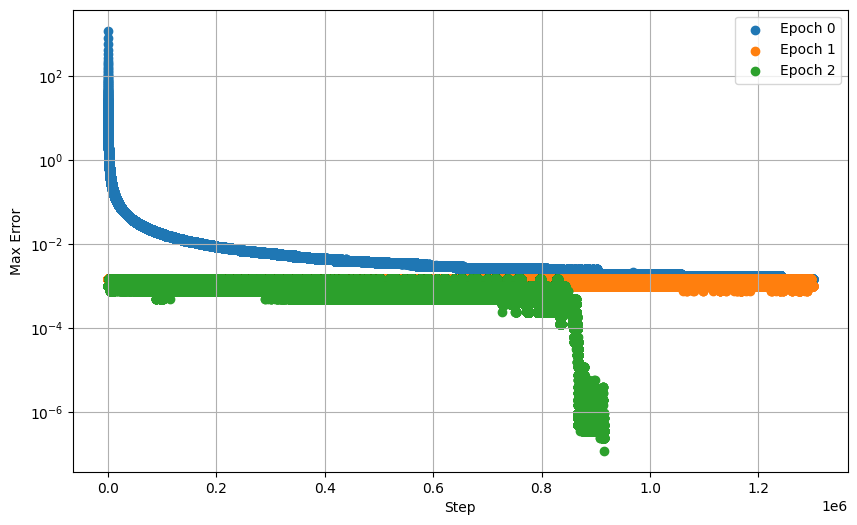

In [31]:
plt.figure(figsize=(10, 6))
for epoch in range(10):
    if len(epochs_data[epoch]) == 1:
        continue
    steps = [step for step, _ in epochs_data[epoch]]
    maxerrs = [maxerr for _, maxerr in epochs_data[epoch]]
    plt.scatter(steps, maxerrs, label=f'Epoch {epoch}')
plt.xlabel('Step')
plt.ylabel('Max Error')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
epochs_data[2]

[(0, 0.0009765625),
 (1, 0.0009765625),
 (2, 0.0009765625),
 (3, 0.0009765625),
 (4, 0.0009765625),
 (5, 0.0009765625),
 (6, 0.0009765625),
 (7, 0.0009765625),
 (8, 0.0009765625),
 (9, 0.0009765625),
 (10, 0.0009765625),
 (11, 0.0009765625),
 (12, 0.0009765625),
 (13, 0.0009765625),
 (14, 0.0009765625),
 (15, 0.0009765625),
 (16, 0.0009765625),
 (17, 0.0009765625),
 (18, 0.0009765625),
 (19, 0.0009765625),
 (20, 0.0009765625),
 (21, 0.0009765625),
 (22, 0.0009765625),
 (23, 0.0009765625),
 (24, 0.0009765625),
 (25, 0.0009765625),
 (26, 0.0009765625),
 (27, 0.0009765625),
 (28, 0.0009765625),
 (29, 0.0009765625),
 (30, 0.0009765625),
 (31, 0.0009765625),
 (32, 0.0009765625),
 (33, 0.0009765625),
 (34, 0.0009765625),
 (35, 0.0009765625),
 (36, 0.0009765625),
 (37, 0.0009765625),
 (38, 0.0009765625),
 (39, 0.0009765625),
 (40, 0.0009765625),
 (41, 0.0009765625),
 (42, 0.0009765625),
 (43, 0.0009765625),
 (44, 0.0009765625),
 (45, 0.0009765625),
 (46, 0.0009765625),
 (47, 0.0009765625),
 (